```text
Nama : Angistu Palamarta

Program ini dibuat untuk menganalisa Confidence Interval dari kolom Age, Login Duration, dan Duration Score.
Dataset yang digunakan adalah dataset dummy yang saya buat pada file "user_dummy_maker.py" dan "daftar.py"



# Library

In [460]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Dataset

In [461]:
df = pd.read_csv("HIGO_User_v2.csv")
df

,user_id,login,logout,user,email,phone,year_of_birth,phone_type,interest,location
0,1,16:59,19:23,saraswati Dhea,saraswati@gmail.com,6287057531624,1989,itel,Food & Beverage,Sukajadi
1,2,04:04,09:42,Ajeng Jayanti,Ajeng@outlook.com,6284592769564,2000,Motorola,News,Bojongloa Kidul
2,3,19:18,00:33,Regina Bella,Regina@outlook.com,6285123908236,1978,Apple,E-commerce,Batununggal
3,4,16:57,18:29,Maulana ayudhia,Maulana@hotmail.com,6288536435042,1977,Motorola,Automotive,Regol
4,5,23:31,02:54,Maulana Muhamad,Maulana@hotmail.com,6288122032958,1994,Sony,E-commerce,Cicendo
...,...,...,...,...,...,...,...,...,...,...
2995,2996,08:36,10:02,Ckasinta ahmad,Ckasinta@hotmail.com,6285432039069,1978,itel,Social Media,Sukasari
2996,2997,20:58,01:23,suci Anisa,suci@hotmail.com,6288104106761,1995,Motorola,Finance,Cicendo
2997,2998,09:19,14:36,Peter zella,Peter@outlook.com,6285954839864,1973,itel,E-commerce,Cinambo
2998,2999,15:59,19:48,ayudhia Peter,ayudhia@yahoo.com,6284571407297,1996,itel,Travel,Bandung Kidul


In [462]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   user_id        3000 non-null   int64
 1   login          3000 non-null   str  
 2   logout         3000 non-null   str  
 3   user           3000 non-null   str  
 4   email          3000 non-null   str  
 5   phone          3000 non-null   int64
 6   year_of_birth  3000 non-null   int64
 7   phone_type     3000 non-null   str  
 8   interest       3000 non-null   str  
 9   location       3000 non-null   str  
dtypes: int64(3), str(7)
memory usage: 234.5 KB


dari informasi yang diberikan, dataset tidak memiliki missing value

In [463]:
df.describe().round()

,user_id,phone,year_of_birth
count,3000.0,3.000000e+03,3000.0
mean,1500.0,6.285497e+12,1981.0
std,866.0,2.550181e+09,12.0
min,1.0,6.281001e+12,1960.0
25%,751.0,6.283291e+12,1971.0
50%,1500.0,6.285441e+12,1981.0
75%,2250.0,6.287705e+12,1993.0
max,3000.0,6.289999e+12,2002.0


# Transform

## Menambahkan Kolom Umur

In [464]:
df["age"] = 2026 - df["year_of_birth"]
df

,user_id,login,logout,user,email,phone,year_of_birth,phone_type,interest,location,age
0,1,16:59,19:23,saraswati Dhea,saraswati@gmail.com,6287057531624,1989,itel,Food & Beverage,Sukajadi,37
1,2,04:04,09:42,Ajeng Jayanti,Ajeng@outlook.com,6284592769564,2000,Motorola,News,Bojongloa Kidul,26
2,3,19:18,00:33,Regina Bella,Regina@outlook.com,6285123908236,1978,Apple,E-commerce,Batununggal,48
3,4,16:57,18:29,Maulana ayudhia,Maulana@hotmail.com,6288536435042,1977,Motorola,Automotive,Regol,49
4,5,23:31,02:54,Maulana Muhamad,Maulana@hotmail.com,6288122032958,1994,Sony,E-commerce,Cicendo,32
...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,08:36,10:02,Ckasinta ahmad,Ckasinta@hotmail.com,6285432039069,1978,itel,Social Media,Sukasari,48
2996,2997,20:58,01:23,suci Anisa,suci@hotmail.com,6288104106761,1995,Motorola,Finance,Cicendo,31
2997,2998,09:19,14:36,Peter zella,Peter@outlook.com,6285954839864,1973,itel,E-commerce,Cinambo,53
2998,2999,15:59,19:48,ayudhia Peter,ayudhia@yahoo.com,6284571407297,1996,itel,Travel,Bandung Kidul,30


## Merapihkan Email

In [465]:
df["email"] = df["email"].str.lower()
df

,user_id,login,logout,user,email,phone,year_of_birth,phone_type,interest,location,age
0,1,16:59,19:23,saraswati Dhea,saraswati@gmail.com,6287057531624,1989,itel,Food & Beverage,Sukajadi,37
1,2,04:04,09:42,Ajeng Jayanti,ajeng@outlook.com,6284592769564,2000,Motorola,News,Bojongloa Kidul,26
2,3,19:18,00:33,Regina Bella,regina@outlook.com,6285123908236,1978,Apple,E-commerce,Batununggal,48
3,4,16:57,18:29,Maulana ayudhia,maulana@hotmail.com,6288536435042,1977,Motorola,Automotive,Regol,49
4,5,23:31,02:54,Maulana Muhamad,maulana@hotmail.com,6288122032958,1994,Sony,E-commerce,Cicendo,32
...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,08:36,10:02,Ckasinta ahmad,ckasinta@hotmail.com,6285432039069,1978,itel,Social Media,Sukasari,48
2996,2997,20:58,01:23,suci Anisa,suci@hotmail.com,6288104106761,1995,Motorola,Finance,Cicendo,31
2997,2998,09:19,14:36,Peter zella,peter@outlook.com,6285954839864,1973,itel,E-commerce,Cinambo,53
2998,2999,15:59,19:48,ayudhia Peter,ayudhia@yahoo.com,6284571407297,1996,itel,Travel,Bandung Kidul,30


## Cek Duplicate

In [466]:
df.drop_duplicates()

,user_id,login,logout,user,email,phone,year_of_birth,phone_type,interest,location,age
0,1,16:59,19:23,saraswati Dhea,saraswati@gmail.com,6287057531624,1989,itel,Food & Beverage,Sukajadi,37
1,2,04:04,09:42,Ajeng Jayanti,ajeng@outlook.com,6284592769564,2000,Motorola,News,Bojongloa Kidul,26
2,3,19:18,00:33,Regina Bella,regina@outlook.com,6285123908236,1978,Apple,E-commerce,Batununggal,48
3,4,16:57,18:29,Maulana ayudhia,maulana@hotmail.com,6288536435042,1977,Motorola,Automotive,Regol,49
4,5,23:31,02:54,Maulana Muhamad,maulana@hotmail.com,6288122032958,1994,Sony,E-commerce,Cicendo,32
...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,08:36,10:02,Ckasinta ahmad,ckasinta@hotmail.com,6285432039069,1978,itel,Social Media,Sukasari,48
2996,2997,20:58,01:23,suci Anisa,suci@hotmail.com,6288104106761,1995,Motorola,Finance,Cicendo,31
2997,2998,09:19,14:36,Peter zella,peter@outlook.com,6285954839864,1973,itel,E-commerce,Cinambo,53
2998,2999,15:59,19:48,ayudhia Peter,ayudhia@yahoo.com,6284571407297,1996,itel,Travel,Bandung Kidul,30


tidak ada data duplicate karena jumlah data masih tetap sama di 3000 data

## Merapihkan Nama User

In [467]:
df["user"] = df["user"].str.title()
df

,user_id,login,logout,user,email,phone,year_of_birth,phone_type,interest,location,age
0,1,16:59,19:23,Saraswati Dhea,saraswati@gmail.com,6287057531624,1989,itel,Food & Beverage,Sukajadi,37
1,2,04:04,09:42,Ajeng Jayanti,ajeng@outlook.com,6284592769564,2000,Motorola,News,Bojongloa Kidul,26
2,3,19:18,00:33,Regina Bella,regina@outlook.com,6285123908236,1978,Apple,E-commerce,Batununggal,48
3,4,16:57,18:29,Maulana Ayudhia,maulana@hotmail.com,6288536435042,1977,Motorola,Automotive,Regol,49
4,5,23:31,02:54,Maulana Muhamad,maulana@hotmail.com,6288122032958,1994,Sony,E-commerce,Cicendo,32
...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,08:36,10:02,Ckasinta Ahmad,ckasinta@hotmail.com,6285432039069,1978,itel,Social Media,Sukasari,48
2996,2997,20:58,01:23,Suci Anisa,suci@hotmail.com,6288104106761,1995,Motorola,Finance,Cicendo,31
2997,2998,09:19,14:36,Peter Zella,peter@outlook.com,6285954839864,1973,itel,E-commerce,Cinambo,53
2998,2999,15:59,19:48,Ayudhia Peter,ayudhia@yahoo.com,6284571407297,1996,itel,Travel,Bandung Kidul,30


## Data Correction phone_type columns

In [468]:
df["phone_type"].unique()

<StringArray>
[        'itel',     'Motorola',        'Apple',         'Sony',
        'Honor', 'Google Pixel',      'Infinix',       'Xiaomi',
       'Huawei',        'TECNO',         'ASUS',      'Samsung',
          'ZTE',         'OPPO',       'realme',         'vivo',
        'Sharp',        'Advan',       'Lenovo',        'Nokia']
Length: 20, dtype: str

In [469]:
df["phone_type"] = df["phone_type"].str.title()
df["phone_type"].unique()

<StringArray>
[        'Itel',     'Motorola',        'Apple',         'Sony',
        'Honor', 'Google Pixel',      'Infinix',       'Xiaomi',
       'Huawei',        'Tecno',         'Asus',      'Samsung',
          'Zte',         'Oppo',       'Realme',         'Vivo',
        'Sharp',        'Advan',       'Lenovo',        'Nokia']
Length: 20, dtype: str

In [470]:
df.loc[df["phone_type"] == "Asus", "phone_type"] = "ASUS"
df.loc[df["phone_type"] == "Zte", "phone_type"] = "ZTE"
df["phone_type"].unique()

<StringArray>
[        'Itel',     'Motorola',        'Apple',         'Sony',
        'Honor', 'Google Pixel',      'Infinix',       'Xiaomi',
       'Huawei',        'Tecno',         'ASUS',      'Samsung',
          'ZTE',         'Oppo',       'Realme',         'Vivo',
        'Sharp',        'Advan',       'Lenovo',        'Nokia']
Length: 20, dtype: str

## Menambahkan Kolom Durasi

In [471]:
df["login"] = pd.to_datetime(df["login"], format="%H:%M")
df["logout"] = pd.to_datetime(df["logout"], format="%H:%M")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   user_id        3000 non-null   int64         
 1   login          3000 non-null   datetime64[us]
 2   logout         3000 non-null   datetime64[us]
 3   user           3000 non-null   str           
 4   email          3000 non-null   str           
 5   phone          3000 non-null   int64         
 6   year_of_birth  3000 non-null   int64         
 7   phone_type     3000 non-null   str           
 8   interest       3000 non-null   str           
 9   location       3000 non-null   str           
 10  age            3000 non-null   int64         
dtypes: datetime64[us](2), int64(4), str(5)
memory usage: 257.9 KB


In [472]:
df.head()

,user_id,login,logout,user,email,phone,year_of_birth,phone_type,interest,location,age
0,1,1900-01-01 16:59:00,1900-01-01 19:23:00,Saraswati Dhea,saraswati@gmail.com,6287057531624,1989,Itel,Food & Beverage,Sukajadi,37
1,2,1900-01-01 04:04:00,1900-01-01 09:42:00,Ajeng Jayanti,ajeng@outlook.com,6284592769564,2000,Motorola,News,Bojongloa Kidul,26
2,3,1900-01-01 19:18:00,1900-01-01 00:33:00,Regina Bella,regina@outlook.com,6285123908236,1978,Apple,E-commerce,Batununggal,48
3,4,1900-01-01 16:57:00,1900-01-01 18:29:00,Maulana Ayudhia,maulana@hotmail.com,6288536435042,1977,Motorola,Automotive,Regol,49
4,5,1900-01-01 23:31:00,1900-01-01 02:54:00,Maulana Muhamad,maulana@hotmail.com,6288122032958,1994,Sony,E-commerce,Cicendo,32


In [473]:
mask = df["logout"] < df["login"]
df.loc[mask, "logout"] += pd.Timedelta(days=1)

df["duration"] = df["logout"] - df["login"]
df["duration_minutes"] = df["duration"].dt.total_seconds() / 60
df

,user_id,login,logout,user,email,phone,year_of_birth,phone_type,interest,location,age,duration,duration_minutes
0,1,1900-01-01 16:59:00,1900-01-01 19:23:00,Saraswati Dhea,saraswati@gmail.com,6287057531624,1989,Itel,Food & Beverage,Sukajadi,37,0 days 02:24:00,144.0
1,2,1900-01-01 04:04:00,1900-01-01 09:42:00,Ajeng Jayanti,ajeng@outlook.com,6284592769564,2000,Motorola,News,Bojongloa Kidul,26,0 days 05:38:00,338.0
2,3,1900-01-01 19:18:00,1900-01-02 00:33:00,Regina Bella,regina@outlook.com,6285123908236,1978,Apple,E-commerce,Batununggal,48,0 days 05:15:00,315.0
3,4,1900-01-01 16:57:00,1900-01-01 18:29:00,Maulana Ayudhia,maulana@hotmail.com,6288536435042,1977,Motorola,Automotive,Regol,49,0 days 01:32:00,92.0
4,5,1900-01-01 23:31:00,1900-01-02 02:54:00,Maulana Muhamad,maulana@hotmail.com,6288122032958,1994,Sony,E-commerce,Cicendo,32,0 days 03:23:00,203.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,1900-01-01 08:36:00,1900-01-01 10:02:00,Ckasinta Ahmad,ckasinta@hotmail.com,6285432039069,1978,Itel,Social Media,Sukasari,48,0 days 01:26:00,86.0
2996,2997,1900-01-01 20:58:00,1900-01-02 01:23:00,Suci Anisa,suci@hotmail.com,6288104106761,1995,Motorola,Finance,Cicendo,31,0 days 04:25:00,265.0
2997,2998,1900-01-01 09:19:00,1900-01-01 14:36:00,Peter Zella,peter@outlook.com,6285954839864,1973,Itel,E-commerce,Cinambo,53,0 days 05:17:00,317.0
2998,2999,1900-01-01 15:59:00,1900-01-01 19:48:00,Ayudhia Peter,ayudhia@yahoo.com,6284571407297,1996,Itel,Travel,Bandung Kidul,30,0 days 03:49:00,229.0


# Analysis

In [474]:
df["age"].describe().round(2)

count    3000.00
mean       44.58
std        12.38
min        24.00
25%        33.00
50%        45.00
75%        55.00
max        66.00
Name: age, dtype: float64

nilai mean dan median (q2 / 50%) berdekatan sehingga kemungkinan tidak ada outlier

## Confidence Interval of Age

### Skewness & Kurtosis

In [475]:
skew = df["age"].skew().round(2)
promt_skew = "Data Normal" if abs(skew) < 0.1 else "Data Miring"
skew_dir = "Normal" if round(skew,3) == 0 else ("Positively" if round(skew,3) > 0 else "Negatively")

kurt = df["age"].kurt().round(2)
kurt_dir = "Leptokurtic Distribution" if kurt > 0 else "Platykurtic Distribution"
out_res_kurt = "Ada outlier" if kurt_dir == "Leptokurtic Distribution" else "Tidak ada outlier"

print("Skewness")
print(skew)
print(promt_skew)
print(skew_dir)
print("")
print("Kurtosis")
print(kurt)
print(kurt_dir)
print(out_res_kurt)

Skewness
0.03
Data Normal
Positively

Kurtosis
-1.21
Platykurtic Distribution
Tidak ada outlier


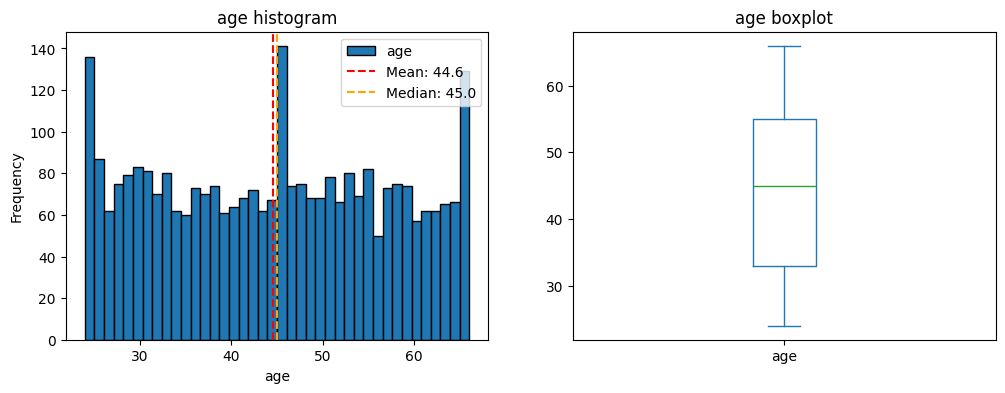

In [476]:
fig, ax = plt.subplots(ncols=2, figsize=(12,4))

df["age"].plot(kind="hist", bins=40, edgecolor="black", ax=ax[0], title="age histogram")
df["age"].plot(kind="box", ax=ax[1], title="age boxplot")
ax[0].axvline(df["age"].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
ax[0].axvline(df["age"].median(), color='orange', linestyle='--', label=f'Median: {df["age"].median():.1f}')
ax[0].set_xlabel("age")
ax[0].legend()

### One-sample Mean Confidence Interval

In [477]:
# hitung mean
mean_age = df["age"].mean()

# hitung standard error
sem = stats.sem(df["age"])

# confidence interval
ci = 0.95
lower, upper = stats.t.interval(
    confidence=ci,
    df=len(df["age"])-1,
    loc=mean_age,
    scale=sem
)

rata_rata = round(mean_age,2)
lower_bound = round(lower,2)
upper_bound = round(upper,2)

print(f"Rata-rata umur: {rata_rata}")
print(f"Confidence Interval :{ci*100}%")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Rata-rata umur: 44.58
Confidence Interval :95.0%
Lower Bound: 44.14
Upper Bound: 45.02


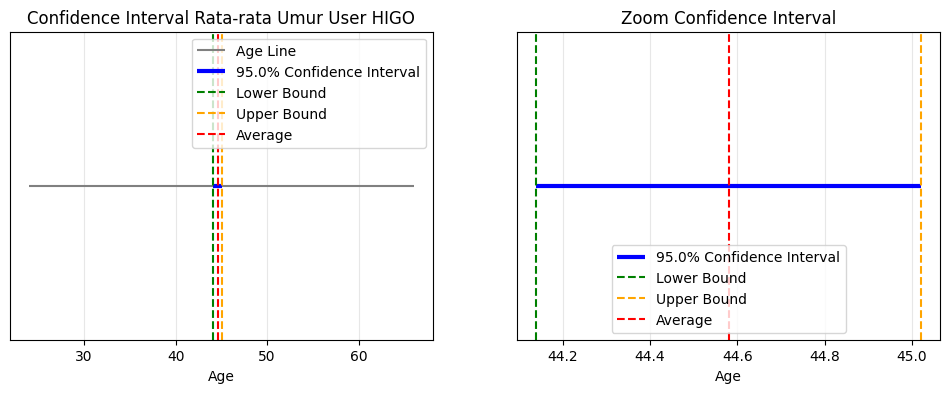

In [478]:
fig, ax = plt.subplots(ncols=2, figsize=(12,4))

# garis CI
ax[0].hlines(y=1, xmin=df["age"].min(), xmax=df["age"].max(), color="grey", label="Age Line")
ax[0].hlines(y=1, xmin=lower_bound, xmax=upper_bound, color="blue", label=f"{ci*100}% Confidence Interval", linewidth=3)
ax[1].hlines(y=1, xmin=lower_bound, xmax=upper_bound, color="blue", label=f"{ci*100}% Confidence Interval", linewidth=3)

# garis vertikal batas
ax[0].axvline(lower_bound, linestyle="--", color="green", label="Lower Bound")
ax[0].axvline(upper_bound, linestyle="--", color="orange", label="Upper Bound")
ax[0].axvline(rata_rata, linestyle="--", color="red", label="Average")
ax[1].axvline(lower_bound, linestyle="--", color="green", label="Lower Bound")
ax[1].axvline(upper_bound, linestyle="--", color="orange", label="Upper Bound")
ax[1].axvline(rata_rata, linestyle="--", color="red", label="Average")

# styling ax[0]
ax[0].set_yticks([])
ax[0].set_xlabel("Age")
ax[0].set_title("Confidence Interval Rata-rata Umur User HIGO")
ax[0].legend()
ax[0].grid(axis="x", alpha=0.3)

# styling ax[1]
ax[1].set_yticks([])
ax[1].set_xlabel("Age")
ax[1].set_title("Zoom Confidence Interval")
ax[1].legend()
ax[1].grid(axis="x", alpha=0.3)

Berdasarkan analisis umur user, rata-rata umur user adalah 44.71 tahun. Dengan tingkat kepercayaan 95%, estimasi rata-rata umur populasi berada pada interval 44.28 hingga 45.15 tahun.

## Confidence Interval of Digital Interest Duration

### Skewness & Kurtosis

In [479]:
skew = df["duration_minutes"].skew().round(2)
promt_skew = "Data Normal" if abs(skew) < 0.1 else "Data Miring"
skew_dir = "Normal" if round(skew,3) == 0 else ("Positively" if round(skew,3) > 0 else "Negatively")

kurt = df["duration_minutes"].kurt().round(2)
kurt_dir = "Leptokurtic Distribution" if kurt > 0 else "Platykurtic Distribution"
out_res_kurt = "Ada outlier" if kurt_dir == "Leptokurtic Distribution" else "Tidak ada outlier"

print("Skewness")
print(skew)
print(promt_skew)
print(skew_dir)
print("")
print("Kurtosis")
print(kurt)
print(kurt_dir)
print(out_res_kurt)

Skewness
0.02
Data Normal
Positively

Kurtosis
-1.06
Platykurtic Distribution
Tidak ada outlier


In [480]:
df["duration_minutes"].describe().round(2)

count    3000.00
mean      179.05
std        88.83
min        10.00
25%       100.00
50%       169.00
75%       258.00
max       349.00
Name: duration_minutes, dtype: float64

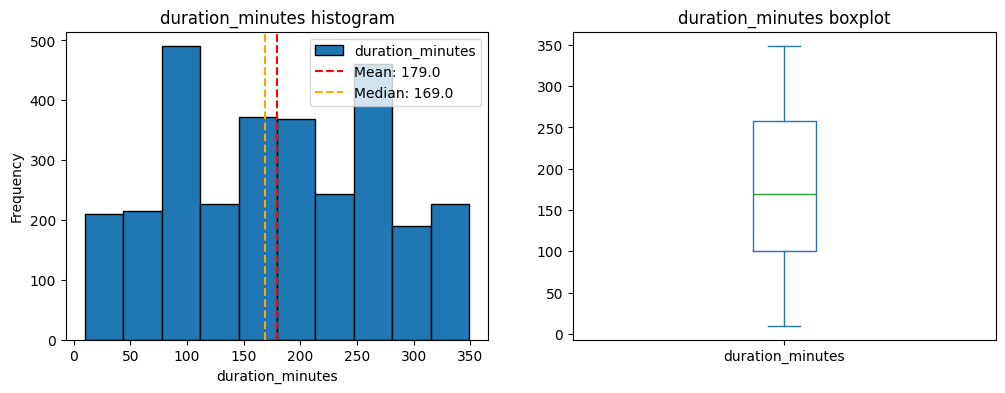

In [481]:
fig, ax = plt.subplots(ncols=2, figsize=(12,4))

df["duration_minutes"].plot(kind="hist", bins=10, edgecolor="black", ax=ax[0], title="duration_minutes histogram")
df["duration_minutes"].plot(kind="box", ax=ax[1], title="duration_minutes boxplot")
ax[0].axvline(df["duration_minutes"].mean(), color='red', linestyle='--', label=f'Mean: {df["duration_minutes"].mean():.1f}')
ax[0].axvline(df["duration_minutes"].median(), color='orange', linestyle='--', label=f'Median: {df["duration_minutes"].median():.1f}')
ax[0].set_xlabel("duration_minutes")
ax[0].legend()

### One-sample Mean Confidence Interval All Digital Interest

In [482]:
# hitung mean
mean_duration = df["duration_minutes"].mean()

# hitung standard error
sem = stats.sem(df["duration_minutes"])

# confidence interval
ci = 0.95
lower, upper = stats.t.interval(
    confidence=ci,
    df=len(df["duration_minutes"])-1,
    loc=mean_duration,
    scale=sem
)

rata_rata_all = round(mean_duration,2)
lower_bound_all = round(lower,2)
upper_bound_all = round(upper,2)

print(f"Rata-rata umur: {rata_rata_all}")
print(f"Confidence Interval: {ci*100}%")
print(f"Lower Bound: {lower_bound_all}")
print(f"Upper Bound: {upper_bound_all}")

Rata-rata umur: 179.05
Confidence Interval: 95.0%
Lower Bound: 175.87
Upper Bound: 182.23


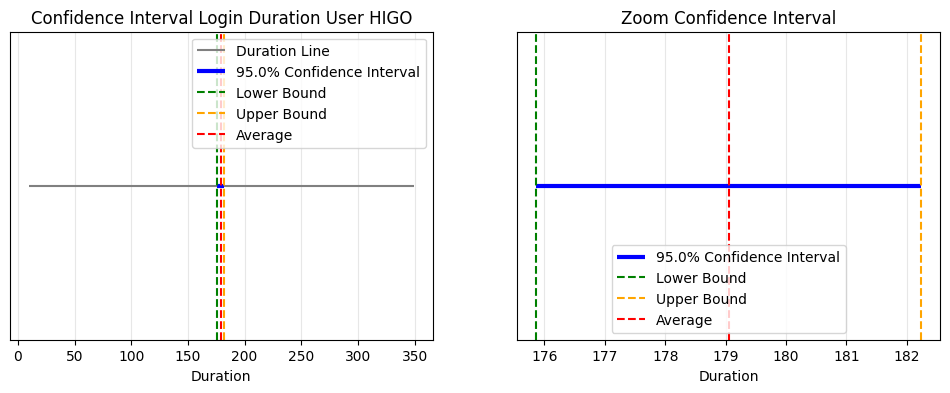

In [483]:
fig, ax = plt.subplots(ncols=2, figsize=(12,4))

# garis CI
ax[0].hlines(y=1, xmin=df["duration_minutes"].min(), xmax=df["duration_minutes"].max(), color="grey", label="Duration Line")
ax[0].hlines(y=1, xmin=lower_bound_all, xmax=upper_bound_all, color="blue", label=f"{ci*100}% Confidence Interval", linewidth=3)
ax[1].hlines(y=1, xmin=lower_bound_all, xmax=upper_bound_all, color="blue", label=f"{ci*100}% Confidence Interval", linewidth=3)

# garis vertikal batas
ax[0].axvline(lower_bound_all, linestyle="--", color="green", label="Lower Bound")
ax[0].axvline(upper_bound_all, linestyle="--", color="orange", label="Upper Bound")
ax[0].axvline(rata_rata_all, linestyle="--", color="red", label="Average")
ax[1].axvline(lower_bound_all, linestyle="--", color="green", label="Lower Bound")
ax[1].axvline(upper_bound_all, linestyle="--", color="orange", label="Upper Bound")
ax[1].axvline(rata_rata_all, linestyle="--", color="red", label="Average")

# styling ax[0]
ax[0].set_yticks([])
ax[0].set_xlabel("Duration")
ax[0].set_title("Confidence Interval Login Duration User HIGO")
ax[0].legend()
ax[0].grid(axis="x", alpha=0.3)

# styling ax[1]
ax[1].set_yticks([])
ax[1].set_xlabel("Duration")
ax[1].set_title("Zoom Confidence Interval")
ax[1].legend()
ax[1].grid(axis="x", alpha=0.3)

### One-sample Mean Confidence Interval Each Digital Interest

In [484]:
durasi_ci = []
n = 0
for kategori in df["interest"].unique():
    n += 1
    
    # hitung rata-rata
    mean_duration = df[df["interest"] == kategori]["duration_minutes"].mean()
    
    # hitung standard error
    sem = stats.sem(df["duration_minutes"])

    # confidence interval
    ci = 0.95
    lower, upper = stats.t.interval(
        confidence=ci,
        df=len(df["duration_minutes"])-1,
        loc=mean_duration,
        scale=sem
    )

    rata_rata_each = round(mean_duration,2)
    lower_bound = round(lower,2)
    upper_bound = round(upper,2)
    
    # print(f"{n}. {kategori}")
    # print(f"mean = {mean_duration}")
    # print(f"Lower Bound: {lower_bound}")
    # print(f"Upper Bound: {upper_bound}")
    # print("-"*30)

    durasi_ci.append({
        "interest": kategori,
        "mean": rata_rata_each,
        "lower": lower_bound,
        "upper": upper_bound
    })

# ubah ke dataframe
ci_df = pd.DataFrame(durasi_ci)
ci_df = ci_df.sort_values("mean")
ci_df

,interest,mean,lower,upper
0,Food & Beverage,152.79,149.61,155.97
8,Education,175.07,171.89,178.25
17,Movies & Streaming,175.09,171.91,178.27
18,Technology,175.38,172.20,178.56
9,Finance,175.53,172.35,178.71
15,Beauty,176.38,173.19,179.56
10,Social Media,177.65,174.47,180.83
13,Cryptocurrency,178.54,175.36,181.72
4,Gaming,178.64,175.46,181.82
1,News,179.17,175.99,182.35


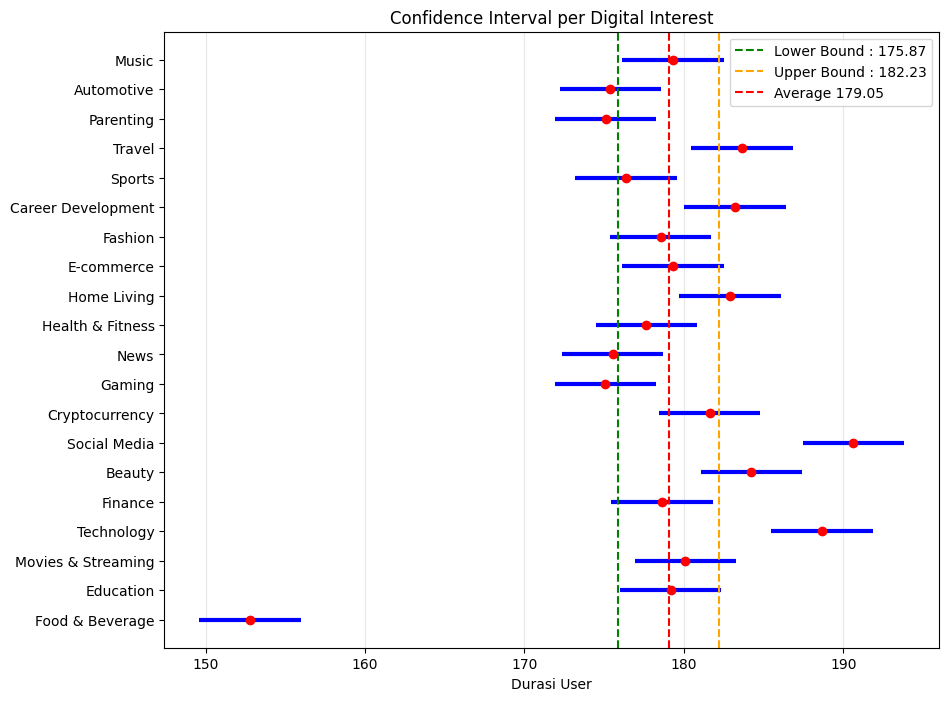

In [485]:
plt.figure(figsize=(10,8))

for i in range(len(ci_df)):
    
    # garis CI horizontal
    plt.hlines(y=i,xmin=ci_df["lower"][i],xmax=ci_df["upper"][i],color="blue",linewidth=3)
    
    # titik mean
    plt.scatter(ci_df["mean"][i], i, color="red", zorder=3)

# bound of all digital insterest
plt.axvline(lower_bound_all, linestyle="--", color="green", label=f"Lower Bound : {lower_bound_all}")
plt.axvline(upper_bound_all, linestyle="--", color="orange", label=f"Upper Bound : {upper_bound_all}")
plt.axvline(rata_rata_all, linestyle="--", color="red", label=f"Average {rata_rata_all:.2f}")

# styling
plt.yticks(range(len(ci_df)), ci_df["interest"])
plt.xlabel("Durasi User")
plt.title("Confidence Interval per Digital Interest")
plt.grid(axis="x", alpha=0.3)
plt.legend()

plt.show()

## Confidence Interval of Digital Interest Score

### Pembagian score dengan univariate

Score 1: 10.00 - 50.00 menit
Score 2: 50.00 - 90.00 menit
Score 3: 90.00 - 110.00 menit
Score 4: 110.00 - 150.00 menit
Score 5: 150.00 - 169.00 menit
Score 6: 169.00 - 208.00 menit
Score 7: 208.00 - 229.00 menit
Score 8: 229.00 - 269.00 menit
Score 9: 269.00 - 290.00 menit
Score 10: 290.00 - 349.00 menit


Text(0.5, 0, 'Score')

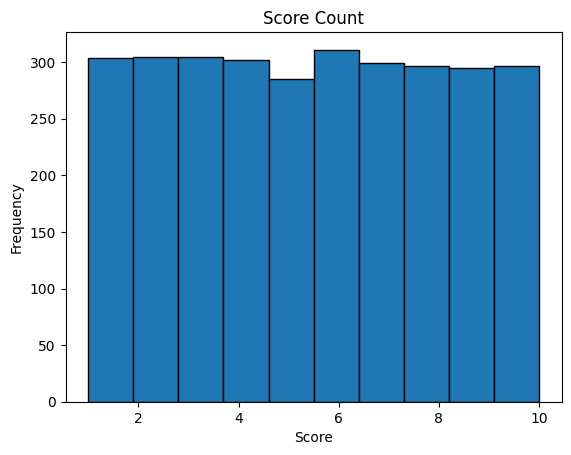

In [486]:
qbins = 10

label = []
for i in range(qbins):
    # print(i+1)
    label.append(i+1)

df["duration_score"], bins = pd.qcut(df["duration_minutes"], q=qbins, labels=label, retbins=True)
# df
# print(bins)
for i in range(len(bins)-1):
    print(f"Score {i+1}: {bins[i]:.2f} - {bins[i+1]:.2f} menit")

df["duration_score"] = df["duration_score"].astype(int)
df["duration_score"].plot(kind="hist", bins=qbins, edgecolor="black", title="Score Count")
plt.xlabel("Score")

### One-sample Mean CI Score to All Digital Interest

In [487]:
# hitung mean
mean_score = df["duration_score"].mean()

# hitung standard error
sem = stats.sem(df["duration_score"])

# confidence interval
ci = 0.95
lower, upper = stats.t.interval(
    confidence=ci,
    df=len(df["duration_score"])-1,
    loc=mean_score,
    scale=sem
)

rata_rata_all = round(mean_score,2)
lower_bound_score = round(lower,2)
upper_bound_score = round(upper,2)

print(f"Rata-rata umur: {rata_rata_all}")
print(f"Confidence Interval: {ci*100}%")
print(f"Lower Bound: {lower_bound_score}")
print(f"Upper Bound: {upper_bound_score}")

Rata-rata umur: 5.47
Confidence Interval: 95.0%
Lower Bound: 5.37
Upper Bound: 5.58


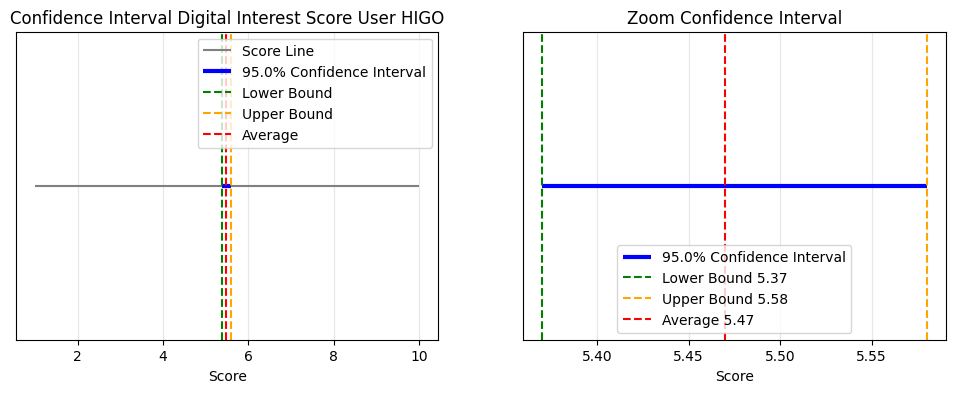

In [488]:
fig, ax = plt.subplots(ncols=2, figsize=(12,4))

# garis CI
ax[0].hlines(y=1, xmin=df["duration_score"].min(), xmax=df["duration_score"].max(), color="grey", label="Score Line")
ax[0].hlines(y=1, xmin=lower_bound_score, xmax=upper_bound_score, color="blue", label=f"{ci*100}% Confidence Interval", linewidth=3)
ax[1].hlines(y=1, xmin=lower_bound_score, xmax=upper_bound_score, color="blue", label=f"{ci*100}% Confidence Interval", linewidth=3)

# garis vertikal batas
ax[0].axvline(lower_bound_score, linestyle="--", color="green", label="Lower Bound")
ax[0].axvline(upper_bound_score, linestyle="--", color="orange", label="Upper Bound")
ax[0].axvline(rata_rata_all, linestyle="--", color="red", label="Average")
ax[1].axvline(lower_bound_score, linestyle="--", color="green", label=f"Lower Bound {lower_bound_score}")
ax[1].axvline(upper_bound_score, linestyle="--", color="orange", label=f"Upper Bound {upper_bound_score}")
ax[1].axvline(rata_rata_all, linestyle="--", color="red", label=f"Average {rata_rata_all}")

# styling ax[0]
ax[0].set_yticks([])
ax[0].set_xlabel("Score")
ax[0].set_title("Confidence Interval Digital Interest Score User HIGO")
ax[0].legend()
ax[0].grid(axis="x", alpha=0.3)

# styling ax[1]
ax[1].set_yticks([])
ax[1].set_xlabel("Score")
ax[1].set_title("Zoom Confidence Interval")
ax[1].legend()
ax[1].grid(axis="x", alpha=0.3)

### One-sample Mean CI Score to Each Digital Interest

In [489]:
score_ci = []
n = 0
for kategori in df["interest"].unique():
    n += 1
    
    # hitung rata-rata
    mean_score = df[df["interest"] == kategori]["duration_score"].mean()
    # hitung standard error
    sem = stats.sem(df["duration_score"])

    # confidence interval
    ci = 0.95
    lower, upper = stats.t.interval(
        confidence=ci,
        df=len(df["duration_score"])-1,
        loc=mean_score,
        scale=sem
    )

    rata_rata_each = round(mean_score,2)
    lower_bound = round(lower,2)
    upper_bound = round(upper,2)
    
    # print(f"{n}. {kategori}")
    # print(f"mean = {mean_score}")
    # print(f"Lower Bound: {lower_bound}")
    # print(f"Upper Bound: {upper_bound}")
    # print("-"*30)

    score_ci.append({
        "interest": kategori,
        "mean": rata_rata_each,
        "lower": lower_bound,
        "upper": upper_bound
    })

# ubah ke dataframe
score_df = pd.DataFrame(score_ci)
score_df = score_df.sort_values("mean")
score_df

,interest,mean,lower,upper
0,Food & Beverage,4.68,4.58,4.78
17,Movies & Streaming,5.29,5.19,5.39
8,Education,5.33,5.23,5.44
18,Technology,5.35,5.25,5.45
9,Finance,5.38,5.28,5.48
15,Beauty,5.40,5.30,5.51
10,Social Media,5.43,5.32,5.53
12,Health & Fitness,5.44,5.34,5.54
19,Home Living,5.45,5.35,5.56
13,Cryptocurrency,5.46,5.36,5.56


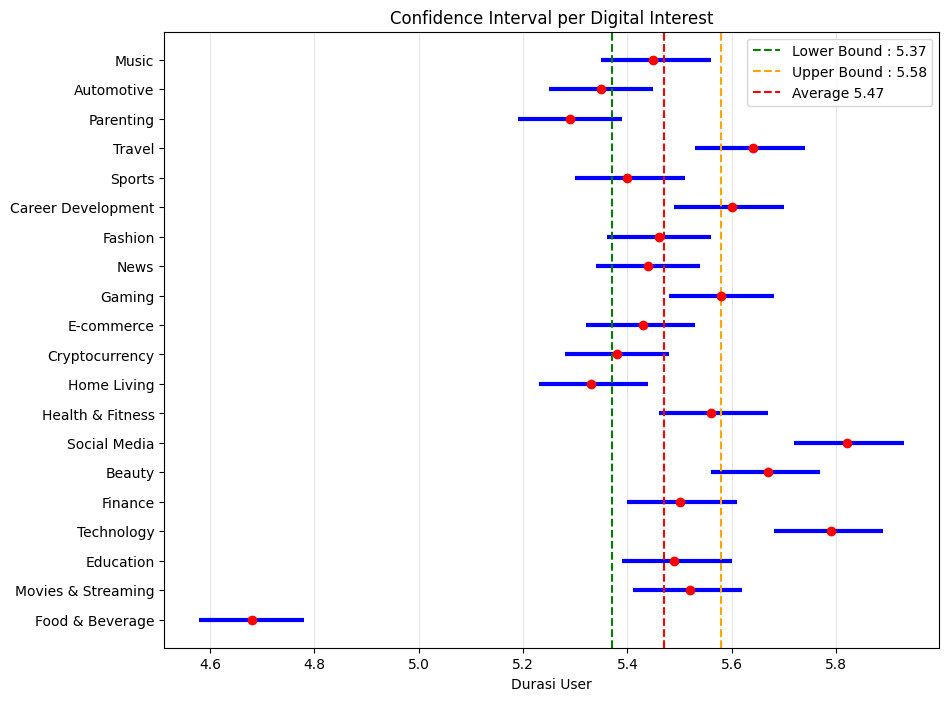

In [490]:
plt.figure(figsize=(10,8))

for i in range(len(score_df)):
    
    # garis CI horizontal
    plt.hlines(y=i,xmin=score_df["lower"][i],xmax=score_df["upper"][i],color="blue",linewidth=3)
    
    # titik mean
    plt.scatter(score_df["mean"][i], i, color="red", zorder=3)

# bound of all digital insterest
plt.axvline(lower_bound_score, linestyle="--", color="green", label=f"Lower Bound : {lower_bound_score}")
plt.axvline(upper_bound_score, linestyle="--", color="orange", label=f"Upper Bound : {upper_bound_score}")
plt.axvline(rata_rata_all, linestyle="--", color="red", label=f"Average {rata_rata_all:.2f}")

# styling
plt.yticks(range(len(score_df)), score_df["interest"])
plt.xlabel("Durasi User")
plt.title("Confidence Interval per Digital Interest")
plt.grid(axis="x", alpha=0.3)
plt.legend()

plt.show()